# 04 — ¿La mejora semanal también mejora el pronóstico diario?

Se reemplaza únicamente el total semanal de 14 por `Memoria_larga` de 15. Se conservan los pesos uniforme, perfil de ocho semanas y boosting de 02, y su pronóstico autónomo. Así se distingue el efecto del total del efecto del reparto; no se reentrena ni se selecciona una nueva forma mirando 2026.

Entradas: predicciones diarias de 02 y predicciones semanales de 15. Salidas: Parquet y Excel propios, sin sobrescribir el experimento original. Alcance: H1, siete días emitidos al lunes, producción/clima conocidos al origen. No es actualización intrasemanal ni prueba de H2–H5 diarios. El candidato semanal fue elegido retrospectivamente: esta evaluación también es retrospectiva.

Se evalúan los mismos días observados para todos los métodos. Los días sin reporte permanecen faltantes. Se añade una sensibilidad en semanas con siete días observados y otra sobre la comparación semanal estricta.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'Datos_analiticos_proyecto').exists())
DIARIO=ROOT/'Datos_analiticos_proyecto/modelo_diario'
SEMANAL=ROOT/'Datos_analiticos_proyecto/modelo_con_proyecciones_teoricas'
FIG=ROOT/'Trabajo escrito/Figuras_resultados'; FIG.mkdir(exist_ok=True)
KEY=['finca','producto','color','variedad']; WK=KEY+['origen']
pred=pd.read_parquet(DIARIO/'predicciones_diarias_2026.parquet')
semanal=pd.read_parquet(SEMANAL/'experimentos_horizontes_2026.parquet')
semanal=semanal.loc[semanal.horizonte.eq(1)]
assert not semanal.duplicated(WK).any()
pred=pred.merge(semanal[WK+['Memoria_larga','Sistema_diario','grupo_comparacion','corte_entrenamiento_nuevo']],on=WK,how='left',validate='many_to_one',suffixes=('','_verificacion'))
assert pred.Memoria_larga.notna().all()
assert np.allclose(pred.Sistema_diario,pred.Sistema_diario_verificacion)
assert pred.corte_entrenamiento_nuevo.le(pred.origen).all()
assert pred.groupby(WK).size().eq(7).all()
pred['Uniforme_memoria']=pred.Memoria_larga/7
pred['Perfil_memoria']=pred.Memoria_larga*pred.peso_perfil
pred['Boosting_memoria']=pred.Memoria_larga*pred.peso_boost
metodos=['Uniforme_semanal','Perfil_8semanas','Boosting_reconciliado','Boosting_diario','Uniforme_memoria','Perfil_memoria','Boosting_memoria']
assert np.isfinite(pred[metodos]).all().all() and pred[metodos].ge(0).all().all()
for metodo in ['Uniforme_memoria','Perfil_memoria','Boosting_memoria']:
    assert np.allclose(pred.groupby(WK)[metodo].sum(),pred.groupby(WK).Memoria_larga.first(),rtol=1e-10,atol=1e-6)
pred['semana_completa']=pred.groupby(WK).tallos.transform('count').eq(7)
print('Semanas:',pred.groupby(WK).ngroups,'días:',len(pred),'observados:',pred.tallos.notna().sum(),'semanas de siete reportes:',pred.loc[pred.semana_completa].groupby(WK).ngroups)
print('Verificado: mismos totales anteriores, claves únicas, cortes temporales y suma diaria = nuevo total semanal.')

Semanas: 4139 días: 28973 observados: 22973 semanas de siete reportes: 274
Verificado: mismos totales anteriores, claves únicas, cortes temporales y suma diaria = nuevo total semanal.


## 1. Precisión: total semanal anterior frente al nuevo

WAPE = suma de errores absolutos / suma de producción observada. MAE y RMSE se expresan en tallos por día y serie. Sesgo positivo significa subestimación. El modelo autónomo no está obligado a sumar al total semanal; los seis repartos sí lo están. Una mejora semanal no garantiza mejorar cada día.

,n,MAE,RMSE,WAPE,sesgo
metodo,,,,,
Boosting_diario,22973.0,543.760215,976.617859,0.267642,146.885264
Boosting_memoria,22973.0,557.780810,1000.787729,0.274543,126.257676
Perfil_memoria,22973.0,566.312001,1010.073669,0.278742,117.839407
Boosting_reconciliado,22973.0,574.785137,1042.424480,0.282913,148.537888
Perfil_8semanas,22973.0,582.121979,1049.502608,0.286524,140.246122
Uniforme_memoria,22973.0,589.883063,1096.666122,0.290344,346.351685
Uniforme_semanal,22973.0,607.345839,1144.514833,0.298940,365.369349


,n,MAE,RMSE,WAPE,sesgo
metodo,,,,,
Boosting_diario,1918.0,605.520074,995.386108,0.247303,188.893620
Boosting_memoria,1918.0,826.912737,1403.253366,0.337722,197.393057
Boosting_reconciliado,1918.0,835.403003,1414.974492,0.341190,172.989611
Perfil_8semanas,1918.0,875.139344,1474.809638,0.357419,172.989611
Perfil_memoria,1918.0,868.653140,1462.484172,0.354770,197.393057
Uniforme_memoria,1918.0,600.340186,944.208074,0.245187,197.393057
Uniforme_semanal,1918.0,600.565261,949.400928,0.245279,172.989611


,n,MAE,RMSE,WAPE,sesgo
metodo,,,,,
Boosting_diario,19411.0,594.294601,1041.201593,0.267565,159.576330
Boosting_memoria,19411.0,601.801947,1053.360458,0.270945,148.388924
Boosting_reconciliado,19411.0,621.977121,1100.956228,0.280029,173.655517
Perfil_8semanas,19411.0,629.144637,1107.465462,0.283255,164.770271
Perfil_memoria,19411.0,610.551071,1062.107243,0.274884,139.354734
Uniforme_memoria,19411.0,647.294240,1173.963354,0.291427,393.457565
Uniforme_semanal,19411.0,667.647501,1226.516743,0.300590,414.761740


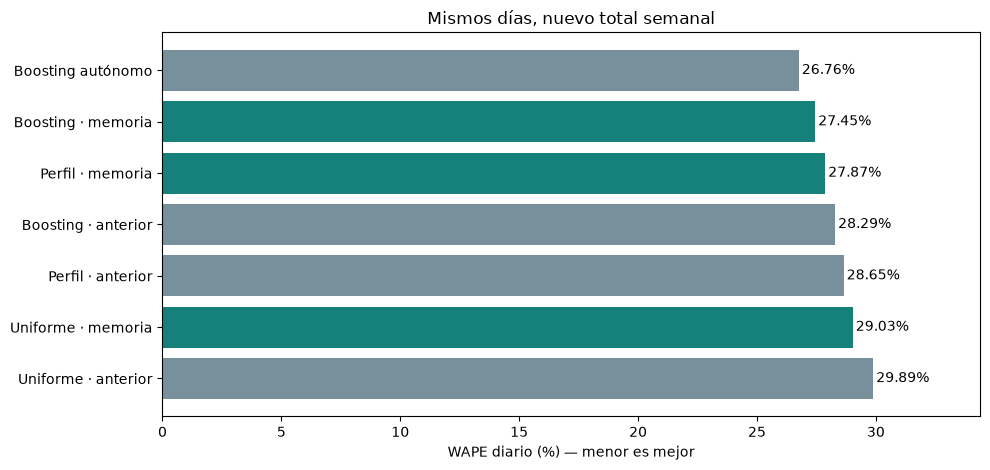

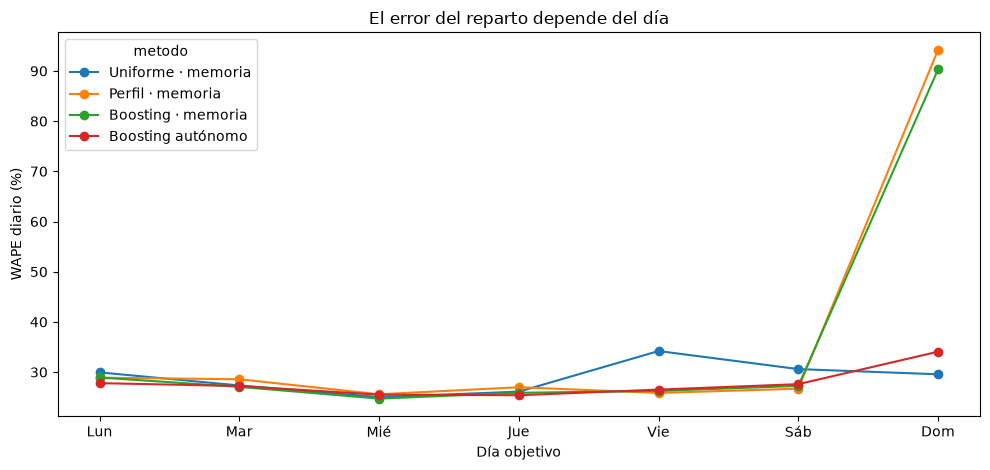

n          MAE         RMSE  \
dia_objetivo metodo                                                    
0            Boosting_diario        3389.0   566.606537   964.988534   
             Boosting_memoria       3389.0   589.435747   998.771284   
             Boosting_reconciliado  3389.0   602.514090  1025.364320   
             Perfil_8semanas        3389.0   604.440366  1029.076750   
             Perfil_memoria         3389.0   588.762827   996.883480   
             Uniforme_memoria       3389.0   610.218614  1049.181768   
             Uniforme_semanal       3389.0   621.515873  1073.056995   
1            Boosting_diario        3921.0   505.784281   875.542257   
             Boosting_memoria       3921.0   502.746311   860.524256   
             Boosting_reconciliado  3921.0   507.111429   872.141213   
             Perfil_8semanas        3921.0   536.723624   924.926368   
             Perfil_memoria         3921.0   530.875027   905.701826   
             Uniforme_memoria       3921.0   507.892198   893.806833   
             Uniforme_semanal       3921.0   517.591341   921.823902   
2            Boosting_diario        3900.0   473.238334   844.348581   
             Boosting_memoria       3900.0   458.617878   790.360997   
             Boosting_reconciliado  3900.0   469.776579   814.344883   
             Perfil_8semanas        3900.0   486.791383   864.187745   
             Perfil_memoria         3900.0   474.657053   836.130820   
             Uniforme_memoria       3900.0   464.169242   828.507909   
             Uniforme_semanal       3900.0   476.873962   868.114332   
3            Boosting_diario        3897.0   495.834978   906.041386   
             Boosting_memoria       3897.0   505.366547   913.321753   
             Boosting_reconciliado  3897.0   520.853950   960.142295   
             Perfil_8semanas        3897.0   544.295907   988.687759   
             Perfil_memoria         3897.0   526.931639   942.514182   
             Uniforme_memoria       3897.0   509.774057   951.917594   
             Uniforme_semanal       3897.0   532.482848  1005.097183   
4            Boosting_diario        3676.0   614.960843  1086.826529   
             Boosting_memoria       3676.0   608.888200  1071.462568   
             Boosting_reconciliado  3676.0   646.764194  1159.539530   
             Perfil_8semanas        3676.0   631.854678  1119.326626   
             Perfil_memoria         3676.0   599.460354  1040.287434   
             Uniforme_memoria       3676.0   793.205511  1440.609024   
             Uniforme_semanal       3676.0   820.003631  1515.918507   
5            Boosting_diario        3901.0   602.665420  1130.402066   
             Boosting_memoria       3901.0   595.069546  1098.760158   
             Boosting_reconciliado  3901.0   617.151838  1152.750864   
             Perfil_8semanas        3901.0   596.597592  1107.917406   
             Perfil_memoria         3901.0   583.085164  1068.126362   
             Uniforme_memoria       3901.0   668.188511  1306.842899   
             Uniforme_semanal       3901.0   690.942776  1364.270789   
6            Boosting_diario         289.0   688.240198  1238.609644   
             Boosting_memoria        289.0  1824.809839  2700.991450   
             Boosting_reconciliado   289.0  1824.649826  2703.908635   
             Perfil_8semanas         289.0  1904.892517  2786.806430   
             Perfil_memoria          289.0  1903.670598  2781.997906   
             Uniforme_memoria        289.0   597.339190   960.271646   
             Uniforme_semanal        289.0   595.736278   974.360097   

                                        WAPE        sesgo  
dia_objetivo metodo                                        
0            Boosting_diario        0.278007   224.159016  
             Boosting_memoria       0.289209   312.971837  
             Boosting_reconciliado  0.295626   324.576753  
             Perfil_8semanas        0.296571   200.175398  
        

n         MAE        RMSE      WAPE  \
producto       metodo                                                           
ACHILLEA       Boosting_diario         49.0   12.535767   18.438961  0.400165   
               Boosting_memoria        49.0   32.631158   40.220415  1.041646   
               Boosting_reconciliado   49.0   48.591329   68.650566  1.551124   
               Perfil_8semanas         49.0   63.896257   95.719988  2.039685   
               Perfil_memoria          49.0   42.065064   55.196826  1.342794   
...                                     ...         ...         ...       ...   
VERONICA SPRAY Boosting_reconciliado  595.0  148.053324  198.249873  0.345948   
               Perfil_8semanas        595.0  147.160501  197.531796  0.343861   
               Perfil_memoria         595.0  146.108161  194.387878  0.341402   
               Uniforme_memoria       595.0  143.393335  197.436206  0.335059   
               Uniforme_semanal       595.0  144.292000  199.292490  0.337159   

                                          sesgo  
producto       metodo                            
ACHILLEA       Boosting_diario        10.810043  
               Boosting_memoria        1.142851  
               Boosting_reconciliado -18.150215  
               Perfil_8semanas       -32.005690  
               Perfil_memoria         -6.812570  
...                                         ...  
VERONICA SPRAY Boosting_reconciliado  17.861924  
               Perfil_8semanas        15.999041  
               Perfil_memoria         20.102322  
               Uniforme_memoria       76.329460  
               Uniforme_semanal       72.715466  

[91 rows x 5 columns]

n         MAE         RMSE      WAPE  \
origen  metodo                                                             
2026-01 Boosting_diario        2861.0  485.980397   830.524418  0.289498   
        Boosting_memoria       2861.0  573.017174  1008.253892  0.341345   
        Boosting_reconciliado  2861.0  569.936712   997.021850  0.339510   
        Perfil_8semanas        2861.0  587.543747  1015.203326  0.349999   
        Perfil_memoria         2861.0  591.486911  1024.719995  0.352348   
        Uniforme_memoria       2861.0  488.960353   810.850003  0.291273   
        Uniforme_semanal       2861.0  490.458196   813.210421  0.292165   
2026-02 Boosting_diario        2676.0  598.583900  1077.843610  0.302464   
        Boosting_memoria       2676.0  597.598084  1081.349108  0.301966   
        Boosting_reconciliado  2676.0  617.175039  1138.534004  0.311858   
        Perfil_8semanas        2676.0  619.208194  1149.369060  0.312886   
        Perfil_memoria         2676.0  598.535764  1091.280113  0.302440   
        Uniforme_memoria       2676.0  649.068384  1203.419480  0.327974   
        Uniforme_semanal       2676.0  667.349815  1264.807113  0.337212   
2026-03 Boosting_diario        3218.0  628.599674  1153.050310  0.269235   
        Boosting_memoria       3218.0  602.996302  1090.747899  0.258269   
        Boosting_reconciliado  3218.0  619.036242  1106.352922  0.265139   
        Perfil_8semanas        3218.0  630.302223  1129.722795  0.269964   
        Perfil_memoria         3218.0  610.812401  1111.691785  0.261616   
        Uniforme_memoria       3218.0  682.558435  1291.850955  0.292346   
        Uniforme_semanal       3218.0  669.479677  1268.954260  0.286744   
2026-04 Boosting_diario        2739.0  528.624998   915.181569  0.236414   
        Boosting_memoria       2739.0  644.427122  1154.353717  0.288204   
        Boosting_reconciliado  2739.0  651.074517  1171.119591  0.291177   
        Perfil_8semanas        2739.0  669.704149  1205.444660  0.299508   
        Perfil_memoria         2739.0  663.487527  1189.532672  0.296728   
        Uniforme_memoria       2739.0  501.342330   873.029559  0.224213   
        Uniforme_semanal       2739.0  504.703164   894.511949  0.225716   
2026-05 Boosting_diario        2681.0  491.715161   823.100037  0.240915   
        Boosting_memoria       2681.0  493.019295   853.986131  0.241554   
        Boosting_reconciliado  2681.0  520.313726   912.391447  0.254927   
        Perfil_8semanas        2681.0  509.388655   891.464837  0.249574   
        Perfil_memoria         2681.0  485.542530   835.087187  0.237891   
        Uniforme_memoria       2681.0  575.256467   997.279622  0.281846   
        Uniforme_semanal       2681.0  605.854987  1058.111200  0.296838   
2026-06 Boosting_diario        3134.0  540.106685   934.052210  0.273614   
        Boosting_memoria       3134.0  523.921785   920.436362  0.265415   
        Boosting_reconciliado  3134.0  548.552018  1003.128460  0.277892   
        Perfil_8semanas        3134.0  565.122720  1025.625816  0.286287   
        Perfil_memoria         3134.0  547.219089   952.548021  0.277217   
        Uniforme_memoria       3134.0  589.814876  1097.914768  0.298796   
        Uniforme_semanal       3134.0  635.119426  1206.650246  0.321746   
2026-07 Boosting_diario        2472.0  530.356031   979.157599  0.264722   
        Boosting_memoria       2472.0  480.945601   849.654674  0.240059   
        Boosting_reconciliado  2472.0  519.213784   957.042561  0.259160   
        Perfil_8semanas        2472.0  517.996046   930.055287  0.258552   
        Perfil_memoria         2472.0  481.266062   828.806849  0.240219   
        Uniforme_memoria       2472.0  608.492642  1148.145769  0.303723   
        Uniforme_semanal       2472.0  653.137493  1258.412458  0.326007   
2026-08 Boosting_diario        3192.0  534.725110  1022.282348  0.269805   
        Boosting_memoria       3192.0  537.952015   985.228804  0.271433   
        

In [2]:
observados=pred.loc[pred.tallos.notna()].copy()
larga=observados.melt(id_vars=WK+['fecha','dia_objetivo','semana_completa','grupo_comparacion','tallos'],value_vars=metodos,var_name='metodo',value_name='prediccion')
def evaluar(g):
    e=g.tallos-g.prediccion
    return pd.Series({'n':len(g),'MAE':e.abs().mean(),'RMSE':np.sqrt((e**2).mean()),'WAPE':e.abs().sum()/g.tallos.sum(),'sesgo':e.mean()})
resumen=larga.groupby('metodo').apply(evaluar)
por_dia=larga.groupby(['dia_objetivo','metodo']).apply(evaluar)
por_producto=larga.groupby(['producto','metodo']).apply(evaluar)
por_mes=larga.groupby([larga.origen.dt.to_period('M').astype(str),'metodo']).apply(evaluar)
completas=larga.loc[larga.semana_completa].groupby('metodo').apply(evaluar)
estricta=larga.loc[larga.grupo_comparacion.eq('principal_estricta_nominal')].groupby('metodo').apply(evaluar)
display(resumen.sort_values('WAPE')); display(completas); display(estricta)
etiquetas={'Uniforme_semanal':'Uniforme · anterior','Perfil_8semanas':'Perfil · anterior','Boosting_reconciliado':'Boosting · anterior','Boosting_diario':'Boosting autónomo','Uniforme_memoria':'Uniforme · memoria','Perfil_memoria':'Perfil · memoria','Boosting_memoria':'Boosting · memoria'}
fig,ax=plt.subplots(figsize=(10,4.8))
orden=resumen.sort_values('WAPE').index
ax.barh([etiquetas[m] for m in orden],resumen.loc[orden,'WAPE']*100,color=['#16817a' if 'memoria' in m else '#78909c' for m in orden])
ax.invert_yaxis();ax.set_xlabel('WAPE diario (%) — menor es mejor');ax.set_title('Mismos días, nuevo total semanal')
for i,v in enumerate(resumen.loc[orden,'WAPE']*100):ax.text(v+.12,i,f'{v:.2f}%',va='center')
ax.set_xlim(0,resumen.WAPE.max()*115);fig.tight_layout();fig.savefig(FIG/'diario_memoria_comparacion.png',dpi=170);plt.show()
seleccion=['Uniforme_memoria','Perfil_memoria','Boosting_memoria','Boosting_diario']
fig,ax=plt.subplots(figsize=(10,4.8))
por_dia.WAPE.unstack()[seleccion].rename(columns=etiquetas).mul(100).plot(ax=ax,marker='o')
ax.set_xticks(range(7),['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']);ax.set_ylabel('WAPE diario (%)');ax.set_xlabel('Día objetivo')
ax.set_title('El error del reparto depende del día');fig.tight_layout();fig.savefig(FIG/'diario_memoria_por_dia.png',dpi=170);plt.show()
display(por_dia);display(por_producto);display(por_mes)

## 2. Tamaño de la mejora, semanas completas y estabilidad

Se remuestrean semanas de origen completas, manteniendo juntos productos, variedades y días, para no tratar cada renglón como independiente. Son intervalos exploratorios del 95 % (1.000 remuestreos); no corrigen la selección retrospectiva del modelo ni toda dependencia entre semanas. Ventaja positiva = menor WAPE del candidato.

Las semanas con siete reportes son una sensibilidad, no una muestra representativa garantizada. Su número y métricas se publican aunque contradigan el resultado general. Las ausencias no se convierten en cero.

In [3]:
rng=np.random.default_rng(42); filas=[]
for nuevo,anterior in [('Uniforme_memoria','Uniforme_semanal'),('Perfil_memoria','Perfil_8semanas'),('Boosting_memoria','Boosting_reconciliado'),('Boosting_memoria','Boosting_diario'),('Boosting_memoria','Uniforme_memoria')]:
    z=pd.DataFrame({'origen':observados.origen,'real':observados.tallos,'ventaja':(observados.tallos-observados[anterior]).abs()-(observados.tallos-observados[nuevo]).abs()}).groupby('origen').sum()
    ix=rng.integers(0,len(z),size=(1000,len(z)))
    vals=100*z.ventaja.to_numpy()[ix].sum(axis=1)/z.real.to_numpy()[ix].sum(axis=1)
    filas.append({'candidato':nuevo,'referencia':anterior,'ventaja_pp':100*z.ventaja.sum()/z.real.sum(),'p025':np.quantile(vals,.025),'p975':np.quantile(vals,.975),'semanas_origen':len(z)})
incertidumbre=pd.DataFrame(filas);display(incertidumbre)
cobertura=pred.groupby('dia_objetivo').agg(dias=('fecha','size'),observados=('tallos','count'),masa_nueva_sin_reporte=('Boosting_memoria',lambda s:s[pred.loc[s.index,'tallos'].isna()].sum()))
cobertura['cobertura']=cobertura.observados/cobertura.dias
display(cobertura)
# La forma no cambia al reemplazar el total. Medimos participación real sólo como diagnóstico posterior.
ok=pred.tallos.notna() & pred.y.gt(0)
forma=pd.DataFrame([{'reparto':nombre,'MAE_participacion_observada':(peso[ok]-pred.loc[ok,'tallos']/pred.loc[ok,'y']).abs().mean()} for nombre,peso in [('Uniforme',pd.Series(1/7,index=pred.index)),('Perfil_8semanas',pred.peso_perfil),('Boosting',pred.peso_boost)]])
display(forma)
pred.to_parquet(DIARIO/'predicciones_diarias_memoria_2026.parquet',index=False)
with pd.ExcelWriter(DIARIO/'resultados_diarios_memoria.xlsx') as writer:
    for nombre,t in [('Resumen',resumen),('Dia_semana',por_dia),('Producto',por_producto),('Mes',por_mes),('Semanas_completas',completas),('Panel_estricto',estricta),('Incertidumbre',incertidumbre),('Cobertura',cobertura),('Forma',forma)]:t.to_excel(writer,sheet_name=nombre)
print('Mejor reparto coherente por WAPE retrospectivo:',resumen.loc[['Uniforme_memoria','Perfil_memoria','Boosting_memoria'],'WAPE'].idxmin())
print('Esto estima producción registrada; el faltante diario no certifica ausencia de corte. No hay benchmark diario del ingeniero en este experimento.')

,candidato,referencia,ventaja_pp,p025,p975,semanas_origen
0,Uniforme_memoria,Uniforme_semanal,0.859529,0.414746,1.290885,35
1,Perfil_memoria,Perfil_8semanas,0.778177,0.346904,1.162495,35
2,Boosting_memoria,Boosting_reconciliado,0.836964,0.384570,1.273234,35
3,Boosting_memoria,Boosting_diario,-0.690103,-1.875545,0.396672,35
4,Boosting_memoria,Uniforme_memoria,1.580094,-0.175732,3.100256,35


,dias,observados,masa_nueva_sin_reporte,cobertura
dia_objetivo,,,,
0,4139,3389,801317.527580,0.818797
1,4139,3921,12145.297281,0.94733
2,4139,3900,11880.523621,0.942257
3,4139,3897,13042.362573,0.941532
4,4139,3676,587390.014558,0.888137
5,4139,3901,19098.829540,0.942498
6,4139,289,793614.288806,0.069824


,reparto,MAE_participacion_observada
0,Uniforme,0.057754
1,Perfil_8semanas,0.055913
2,Boosting,0.054391


Mejor reparto coherente por WAPE retrospectivo: Boosting_memoria
Esto estima producción registrada; el faltante diario no certifica ausencia de corte. No hay benchmark diario del ingeniero en este experimento.


## 3. Sensibilidad del piloto SARIMA/SARIMAX al nuevo total

Se reutilizan los pronósticos autónomos y estados de convergencia de 03; sólo cambia el total usado para reconciliar. Se comparan todos los métodos en los mismos días de las mismas tres series. No se extrapola esta muestra al conjunto de 22.973 días de la evaluación principal.

In [4]:
pilot=pd.read_parquet(DIARIO/'comparacion_sarima_diaria.parquet')
pilot=pilot.merge(pred[KEY+['origen','fecha','Memoria_larga','Uniforme_memoria','Perfil_memoria','Boosting_memoria']],on=KEY+['origen','fecha'],how='left',validate='one_to_one')
for metodo in ['SARIMA','SARIMAX']:
    suma=pilot.groupby(WK)[metodo].transform('sum')
    completos=pilot.groupby(WK)[metodo].transform('count').eq(7)
    pilot[metodo+'_memoria']=np.where(completos&suma.gt(0),pilot[metodo]/suma*pilot.Memoria_larga,np.nan)
    ok=pilot.groupby(WK)[metodo+'_memoria'].count().eq(7)
    assert np.allclose(pilot.groupby(WK)[metodo+'_memoria'].sum()[ok],pilot.groupby(WK).Memoria_larga.first()[ok])
metodos_piloto=['Semana_anterior','SARIMA','SARIMAX','SARIMA_reconciliado','SARIMAX_reconciliado','SARIMA_memoria','SARIMAX_memoria']+metodos
comunes=pilot.loc[pilot.tallos.notna()&pilot[metodos_piloto].notna().all(axis=1)]
lp=comunes.melt(id_vars=KEY+['origen','fecha','tallos'],value_vars=metodos_piloto,var_name='metodo',value_name='prediccion')
resumen_piloto=lp.groupby('metodo').apply(evaluar)
display(resumen_piloto.sort_values('WAPE'))
pilot.to_parquet(DIARIO/'piloto_sarima_memoria.parquet',index=False)
with pd.ExcelWriter(DIARIO/'resultados_diarios_memoria.xlsx',mode='a',engine='openpyxl',if_sheet_exists='replace') as writer:
    resumen_piloto.to_excel(writer,sheet_name='Piloto_SARIMA')
print('Comparación piloto:',len(comunes),'días comunes; verificar convergencia en 03.')

,n,MAE,RMSE,WAPE,sesgo
metodo,,,,,
SARIMAX,135.0,2214.360678,3039.691113,0.244919,262.904956
SARIMA,135.0,2252.108548,3060.919575,0.249094,235.593344
Perfil_memoria,135.0,2540.964394,3457.420375,0.281043,1219.266411
Boosting_memoria,135.0,2572.849940,3459.344298,0.284570,1197.655300
Perfil_8semanas,135.0,2707.807733,3657.771844,0.299496,1329.792328
Boosting_reconciliado,135.0,2720.137613,3666.916124,0.300860,1309.422515
Uniforme_memoria,135.0,2778.692984,3884.883372,0.307337,2136.472490
Boosting_diario,135.0,2789.068408,3691.773143,0.308484,1120.814900
SARIMA_memoria,135.0,2793.935656,3835.374112,0.309023,2095.874536


Comparación piloto: 135 días comunes; verificar convergencia en 03.


## 4. Qué se puede concluir

Con las bases de esta revisión, el boosting reconciliado baja de **28,29 % a 27,45 % de WAPE** al cambiar el total semanal. El intervalo exploratorio de la mejora es **0,38 a 1,27 puntos**. Su MAE baja de 574,79 a 557,78 tallos. Es una mejora del sistema coherente, pero el boosting autónomo todavía obtiene menor WAPE (**26,76 %**) y menor MAE (**543,76 tallos**); su suma semanal es libre.

La lectura depende de la cobertura: únicamente **274 semanas-serie** tienen siete días observados (1.918 días). En ese subconjunto el reparto uniforme con memoria obtiene **24,52 %**, el autónomo **24,73 %** y el boosting reconciliado **33,77 %**. Es una advertencia concreta de que el patrón histórico de reporte no representa bien todas las semanas; no se debe seleccionar el método para una semana usando su completitud futura, desconocida al emitir.

En el panel estricto del benchmark semanal (19.411 días) se mantiene la mejora: boosting reconciliado **28,00 % → 27,09 %**, frente a **26,76 %** del autónomo. Hay progreso para distribuir el total, pero no se ha demostrado suficiencia operativa ni superioridad frente a un ingeniero diario. Falta confirmar el significado de días sin reporte y fijar el método antes de evaluar fechas nuevas. Una actualización durante la semana sería otro experimento con nuevas reglas de disponibilidad.

Para entrenamiento frente a evaluación, consultar 17: reconstruye el último ajuste diario y el sistema compuesto, mantiene separado su test de agosto del acumulado de enero–agosto y conserva aquí las predicciones originales.